In [85]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [86]:
df=pd.read_csv("Exam_Score_Prediction (1).csv")
df

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19997,18,other,bba,6.50,71.3,yes,5.0,good,self-study,low,easy,86.5
19996,19998,18,male,b.com,3.71,41.6,no,5.9,average,coaching,medium,moderate,60.9
19997,19999,19,other,diploma,7.88,68.2,yes,4.6,poor,group study,low,easy,64.5
19998,20000,19,male,bba,4.60,76.3,no,6.1,good,self-study,medium,moderate,79.0


In [87]:
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [88]:
df.tail()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
19995,19997,18,other,bba,6.50,71.3,yes,5.0,good,self-study,low,easy,86.5
19996,19998,18,male,b.com,3.71,41.6,no,5.9,average,coaching,medium,moderate,60.9
19997,19999,19,other,diploma,7.88,68.2,yes,4.6,poor,group study,low,easy,64.5
19998,20000,19,male,bba,4.60,76.3,no,6.1,good,self-study,medium,moderate,79.0
19999,20001,20,male,b.sc,7.50,47.9,yes,7.5,poor,coaching,medium,moderate,71.0


In [89]:
df.shape

(20000, 13)

In [90]:
df.isnull()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,False,False,False,False,False,False,False,False,False,False,False,False,False
19996,False,False,False,False,False,False,False,False,False,False,False,False,False
19997,False,False,False,False,False,False,False,False,False,False,False,False,False
19998,False,False,False,False,False,False,False,False,False,False,False,False,False


In [91]:
df.isnull().sum()

student_id          0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [92]:
d=df.dropna()
d

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19997,18,other,bba,6.50,71.3,yes,5.0,good,self-study,low,easy,86.5
19996,19998,18,male,b.com,3.71,41.6,no,5.9,average,coaching,medium,moderate,60.9
19997,19999,19,other,diploma,7.88,68.2,yes,4.6,poor,group study,low,easy,64.5
19998,20000,19,male,bba,4.60,76.3,no,6.1,good,self-study,medium,moderate,79.0


In [93]:
d.shape

(20000, 13)

In [94]:
from sklearn.preprocessing import LabelEncoder

In [101]:
#list of columns to convert from categorical to numerical
columns  = ["gender","course","internet_access","sleep_quality","study_method","facility_rating","exam_difficulty"]



#store encoders and  dictionaries

encoders = {}
mappings = {}

for col in columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

    #save encoder
    encoders[col] = le

    # create mapping dictionary
    mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

#print all mappings

for col, mapping in mappings.items():
    print(f"{col}:", mapping) 

gender: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}
course: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4), np.int64(5): np.int64(5), np.int64(6): np.int64(6)}
internet_access: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
sleep_quality: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}
study_method: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4)}
facility_rating: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}
exam_difficulty: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}


In [102]:
print(type(encoders["gender"]))

<class 'sklearn.preprocessing._label.LabelEncoder'>


In [112]:
import pickle

# Save mappings dictionary
# with open("encoder_mapping.pkl", "wb") as f:
   #pickle.dump(mappings, f)

#Save encoders also (optional but useful)
with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)   

In [104]:
for col, encoder in encoders.items():
    print(f"{col}: {encoder.classes_}")

gender: [0 1 2]
course: [0 1 2 3 4 5 6]
internet_access: [0 1]
sleep_quality: [0 1 2]
study_method: [0 1 2 3 4]
facility_rating: [0 1 2]
exam_difficulty: [0 1 2]


In [105]:
encoders["study_method"].classes_

array([0, 1, 2, 3, 4])

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  int64  
 3   course            20000 non-null  int64  
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  int64  
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  int64  
 9   study_method      20000 non-null  int64  
 10  facility_rating   20000 non-null  int64  
 11  exam_difficulty   20000 non-null  int64  
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(9)
memory usage: 2.0 MB


## DATA CLEANING AND PREPROCESSING

In [107]:
# Convert categorical columns to numerical using label encoder
from sklearn.preprocessing import LabelEncoder

In [124]:
from sklearn.preprocessing import LabelEncoder

gender_encoder = LabelEncoder()
course_encoder =  LabelEncoder()
internet_encoder = LabelEncoder()
sleep_encoder = LabelEncoder()
study_encoder = LabelEncoder()
facility_encoder = LabelEncoder()
exam_encoder = LabelEncoder()

df['gender'] = gender_encoder.fit_transform(df['gender'])

df['course'] = gender_encoder.fit_transform(df['course'])


df['internet_access'] = internet_encoder.fit_transform(df['internet_access'])

df['sleep_quality'] = sleep_encoder.fit_transform(df['sleep_quality'])

df['study_method'] = sleep_encoder.fit_transform(df['study_method'])

df['study_method'] = study_encoder.fit_transform(df['study_method'])

df['facility_rating'] = facility_encoder.fit_transform(df['facility_rating'])

df['exam_difficulty'] = sleep_encoder.fit_transform(df['exam_difficulty'])

KeyError: 'course'

In [108]:
import seaborn as sns

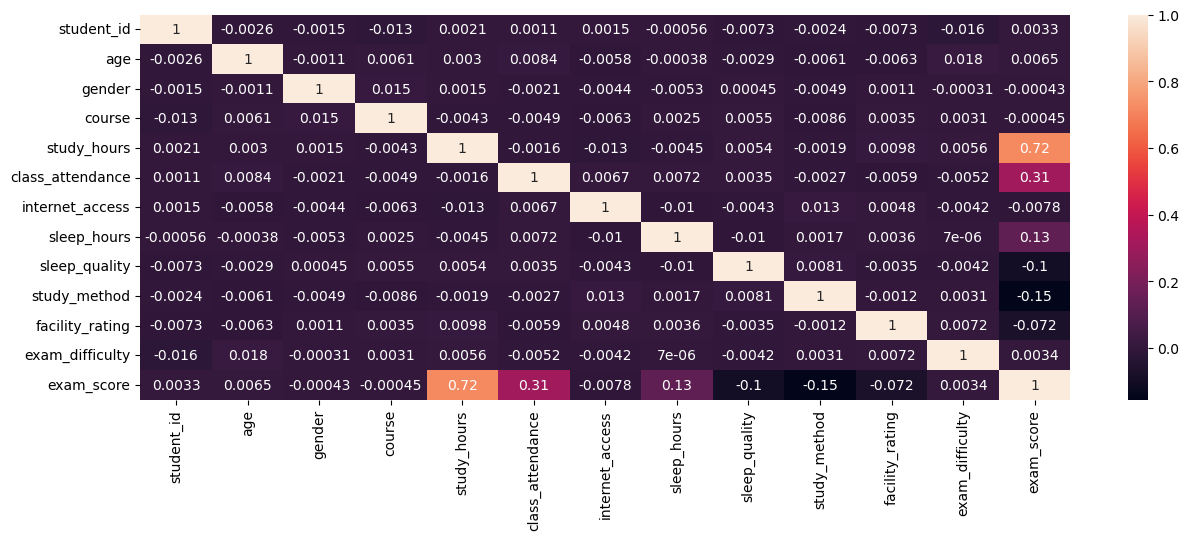

In [109]:
# to find correlation between the variables
corr = df.corr()
plt.figure(figsize=(15,5))
sns.heatmap(corr,annot=True)
plt.show()

In [110]:
# Drop non correlated columns
df.drop('exam_difficulty',axis=1,inplace=True)
df.drop('student_id',axis=1,inplace=True)
df.drop('age',axis=1,inplace=True)
df.drop('course',axis=1,inplace=True)

In [23]:
df.head()

,gender,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_score
0,1,2.78,92.9,1,7.4,2,0,1,58.9
1,2,3.37,64.8,1,4.6,0,3,2,54.8
2,1,7.88,76.8,1,8.5,2,0,0,90.3
3,2,0.67,48.4,1,5.8,0,3,1,29.7
4,0,0.89,71.6,1,9.8,2,0,1,43.7


## EXPLORATORY DATA ANALYSIS

## SCATTER PLOT

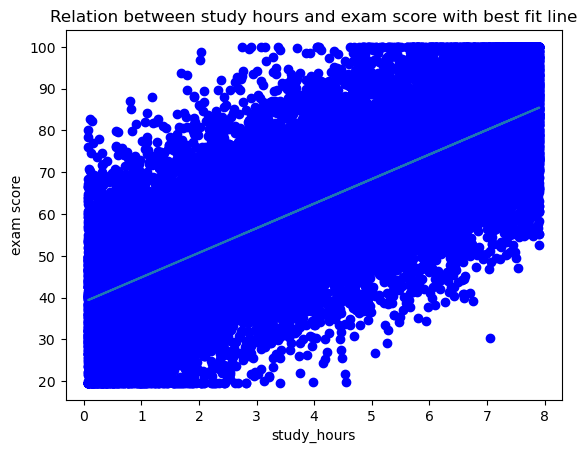

In [26]:
#Scatter plot for analysis the relation between study hours and Exam score
x=df['study_hours']
y=df['exam_score']
plt.scatter(x,y, color='blue',marker = 'o')
m,b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)
plt.xlabel('study_hours')
plt.ylabel('exam score')
plt.title('Relation between study hours and exam score with best fit line')
plt.show()

## HISTOGRAM

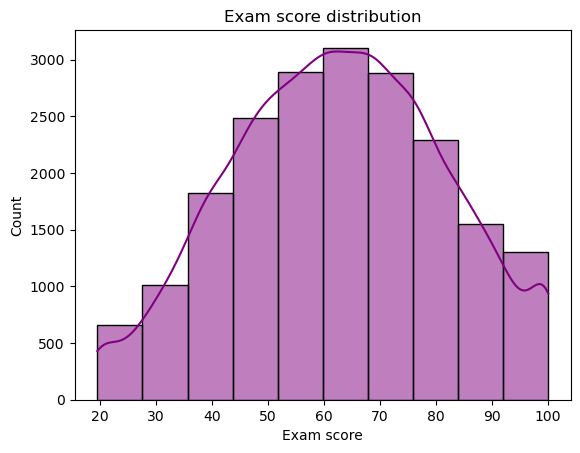

In [27]:
# Exam score distribution
sns.histplot(df['exam_score'],bins = 10, kde = True, color = 'purple')
plt.xlabel('Exam score')
plt.title('Exam score distribution')
plt.show()

## PIE PLOT

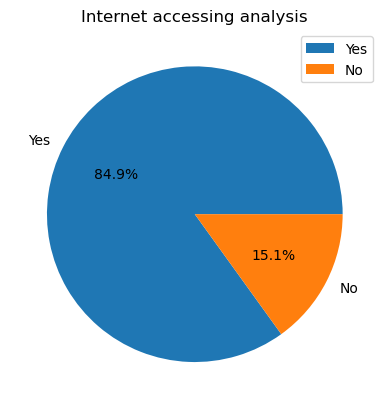

In [28]:
# Relation between internet accessing analysis
labels= ['Yes','No']
count = df['internet_access'].value_counts()
plt.pie(count,labels=labels,autopct='%1.1f%%')
plt.legend()
plt.title('Internet accessing analysis')
plt.show()

## TRAIN TEST SPLIT

In [29]:
# Split the whole dataset to X and Y to train the model
X = df.drop('exam_score',axis=1)
X.head()

,gender,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating
0,1,2.78,92.9,1,7.4,2,0,1
1,2,3.37,64.8,1,4.6,0,3,2
2,1,7.88,76.8,1,8.5,2,0,0
3,2,0.67,48.4,1,5.8,0,3,1
4,0,0.89,71.6,1,9.8,2,0,1


In [30]:
y = df['exam_score']
y.head()

0    58.9
1    54.8
2    90.3
3    29.7
4    43.7
Name: exam_score, dtype: float64

In [31]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=24)

In [32]:
from sklearn.preprocessing import StandardScaler
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
from sklearn.decomposition import PCA
#Apply PCA
pca = PCA(n_components=2) # reduce to 2 principal components
X_pca = pca.fit_transform(X_scaled)

In [34]:
# Convert PCA result to DataFrame
X_pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
print("PCA Transformed Data (First 5 rows):")
print(X_pca_df.head())

PCA Transformed Data (First 5 rows):
        PC1       PC2
0  0.209138  0.230330
1  0.132118 -0.654929
2 -0.906926 -0.156686
3  0.700076 -0.073001
4  0.622394  1.285595


In [35]:
# Explained variance ratio
explained_var = pca.explained_variance_ratio_
print("\nExplained Variance Ratio:")
for i, var in enumerate(explained_var):
    print(f"PC{i+1}: {var:.2f}")


Explained Variance Ratio:
PC1: 0.13
PC2: 0.13


In [36]:
# Feature importance (average absolute loading)
feature_importance = np.abs(pca.components_).mean(axis=0)
feature_rank = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance}).sort_values(by='Importance',ascending=False)

print("\nFeature ranking by PCA importance:")
print(feature_rank)


Feature ranking by PCA importance:
            Feature  Importance
1       study_hours    0.388447
3   internet_access    0.384545
6      study_method    0.363603
4       sleep_hours    0.341054
5     sleep_quality    0.290165
2  class_attendance    0.222815
0            gender    0.216556
7   facility_rating    0.097562


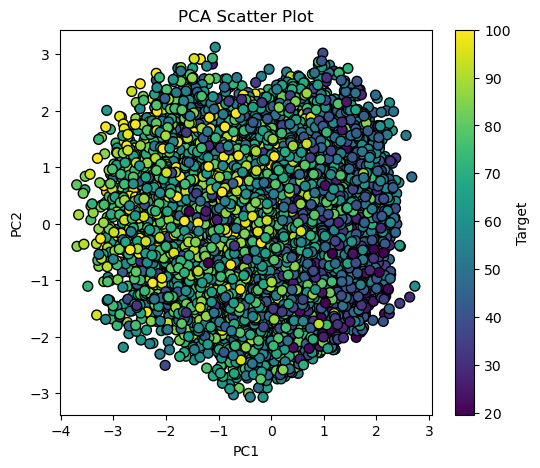

In [37]:
# Optional: plot PCA scatter
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap= 'viridis', edgecolor= 'k', s=50)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Scatter Plot')
plt.colorbar(label='Target')
plt.savefig('PCA')
plt.show()

# MODELING

## LINERAR REGRESSION

In [38]:
from sklearn.linear_model import LinearRegression
model_LR = LinearRegression()
model_LR.fit(X_train,y_train)

LinearRegression()

In [39]:
y_pred = model_LR.predict(X_test)

In [40]:
# To check the accuracy of Linear Regression Model
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R^2 score:",r2)

R^2 score: 0.6735781037072115


In [41]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Display Results
print("R-squared (R2)      :",r2)   
print("Mean Absolute Error :",mae)
print("Mean Squared Error  :",mse)
print("Root MSE            :",rmse)

R-squared (R2)      : 0.6735781037072115
Mean Absolute Error : 8.852160743478624
Mean Squared Error  : 118.66730561240028
Root MSE            : 10.893452419338889


In [42]:
from sklearn.ensemble import RandomForestRegressor
model_RFR = RandomForestRegressor()
model_RFR.fit(X_train,y_train)

RandomForestRegressor()

In [43]:
y_pred = model_RFR.predict(X_test)

In [44]:
# To check the accuracy of this Model
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R^2 score:",r2)

R^2 score: 0.6962202437677365


## SVR

In [53]:
from sklearn.svm import SVR

model_SVR = SVR()
model_SVR.fit(X_train, y_train)

SVR()

y_pred = model_SVR.predict(X_test)

In [55]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R^2 score:",r2)

R^2 score: 0.6008981918395595


## KNeighbors Regressor

In [58]:
from sklearn.neighbors import KNeighborsRegressor
model_KNR = KNeighborsRegressor()
model_KNR.fit(X_train,y_train)

KNeighborsRegressor()

In [59]:
y_pred = model_KNR.predict(X_test)

In [60]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R^2 score:",r2)

R^2 score: 0.6275113034179658


## MLP REGRESSOR

In [120]:
from sklearn.neural_network import MLPRegressor
model_MLPR = MLPRegressor()
model_MLPR.fit(X_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor()

In [67]:
y_pred = model_MLPR.predict(X_test)

In [69]:
r2 = r2_score(y_test, y_pred)
print("R^2 score:",r2)

R^2 score: 0.721461530810076


In [ ]:
# here MLPR showed the highest R^2 value with 0.72

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [ ]:
import joblib

In [123]:
# Save Encoders

encoders = {
    "gender": gender_encoder,
    "internet_access": internet_encoder,
    "sleep_quality": sleep_encoder,
    "study_method": study_encoder,
    "facility_rating": facility_encoder
}

joblib.dump(encoders, "encoders.pkl")

# Save Scaler


joblib.dump(scaler, "scaler.pkl")

# Save Model


joblib.dump(model, "exam_model.pkl")


print("Model, scalar and encoders saved successfully")


Model, scalar and encoders saved successfully
